## From model to production

We're going to use a computer vision example to look at the end-to-end process of creating a deep learning application. More specifically, we're going to build a bear classifier! In the process, we'll discuss the capabilities and constraints of deep learning, explore how to create datasets, look at possible gotchas when using deep learning in practice, and more

## The practice of Deep Learning

When implementing deep learning in practical applications, it's crucial to set realisti expectations rather than viewing it as a magical solution.

Our approach to these models involves two primary considerations:

- **Constraints**: These arise from various factors, including the quality and volume of available data, computational resources, the inherent complexity of the problem, and real-world ethical or security concerns
*(ex. A model trained only on daytime photos will not be able to "see" at night.)*

- **Capabilities**: This refers to a model's ability to discern intricate patterns from limited data, automate repetitive actions and apply learned knowledge to make predictions on unseen data.
*(ex. Recognizing a disease from an X-ray better than an inexperienced eye or finding hidden correlations between chemical variables in a wine.)*

The best thing to do is to keep an open mind. If you remain open to the possibility that deep learning might solve part of your problem with less data or complexity than you expect, then it is possible to design a process where you can find the specific capabilities and constraints related to your particular problem as you work through the process.



## Starting your project

When selecting a project, the most important consideration is data availability. The goal is not to find the perfect dataset or project, but just to get started and iterate from there.

It is recommended to iterate from end to end in your project, meaning that you should first complete every step as well as you can in a reasonable amount of time, all the way to the end. For instance, if your final goal is an application that runs on a mobile phone, then that should be what you have after each iteration.

When you are just starting out with deep learning, it's not a good idea to branch out into very different areas, to places that deep learning has not been applied to before. That's because if your model doesn't work at first, you will not know whether it is because you have made a mistake, or if the very problem you are trying to solve is simply not solvable with deep learning.

So, it is best at first to start with something where you can find an example online.

You can find the dataset we will use in the following link:
https://www.kaggle.com/datasets/hoturam/bear-dataset

In [2]:
!pip install -Uqq fastbook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.5 MB/s eta 0:00:00


In [2]:
from fastai.vision.all import *

from fastbook import *

from fastai.vision.widgets import *

In [6]:

path = "/home/davidebui/DeepLearning/Lesson2/Bear_dataset"
bear_types = 'grizzly','teddy','polar','black', 'panda'

bears = DataBlock(
    blocks = (ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct = 0.2, seed = 42),
    get_y = parent_label,
    item_tfms = Resize(224)
)

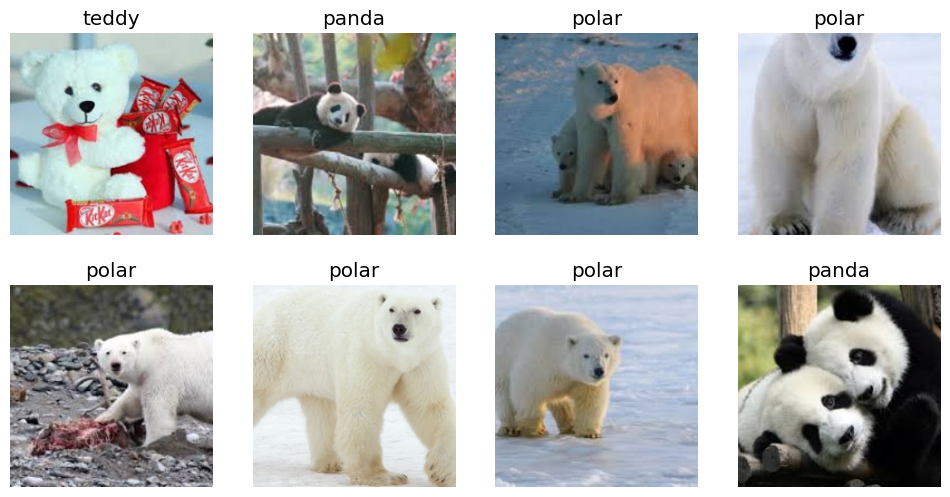

In [37]:
dls = bears.dataloaders(path)
dls.show_batch(max_n = 8)

In [38]:

failed = verify_images(get_image_files(path))
failed.map(Path.unlink)

[]

By default **Resize** crops the images to fit a square shape of the size requested, using the full width or height. This can result in losing some important details. Alternatively, you can ask fastai to pad the images with zeros(black), or squish/stretch them:

- **ResizeMethod.Squish/Stretch**: if you _Squish_ or _Stretch_ the images they end up as unrealistic shapes, leading to a model that learns that things look different to how they actually are, which you wuold expect to result in lower accuracy.

- **ResizeMethod.Pad, pad_mode = 'zeros'**: if we _pad_ the images then we have a whole lot of empty space, which is just wasted computation for our model and results in a lower effectiver resolution for the part of the image we actually use.

What we normally do in practice is to randomly select part of the image, and crop to just that part. On each epoch (which is one complete pass through all of our images in the dataset) we randomly select a different part of each image. This means that our model can learn to focus on, and recognize, different features in our images

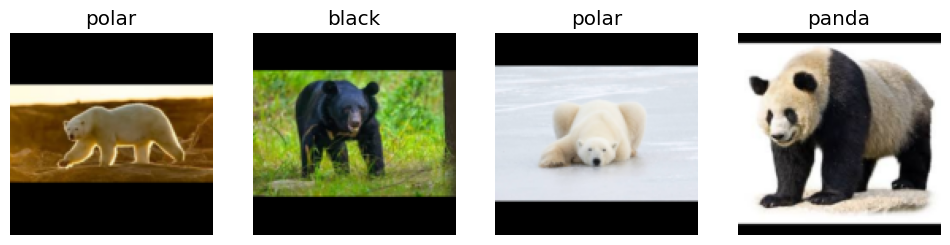

In [ ]:
# hide
ex_bears = bears.new(item_tfms = Resize(128, ResizeMethod.Pad, pad_mode = 'zeros'))
ex_dls = ex_bears.dataloaders(path)
ex_dls.valid.show_batch(max_n = 4, nrows = 1)

In [39]:
learn = vision_learner(dls, resnet18, metrics = error_rate)
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,2.161373,0.684261,0.262295,00:30


epoch,train_loss,valid_loss,error_rate,time
0,0.936605,0.266739,0.065574,00:43
1,0.641061,0.079008,0.032787,00:40
2,0.453888,0.068083,0.032787,00:39
3,0.350227,0.065201,0.032787,00:38


Now let's see whether the mistakes the model is making are mainly thinking that grizzlies are teddies or that grizzlies are black bears, or something else. To visualize this, we can create a ***confusion matrix***:

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

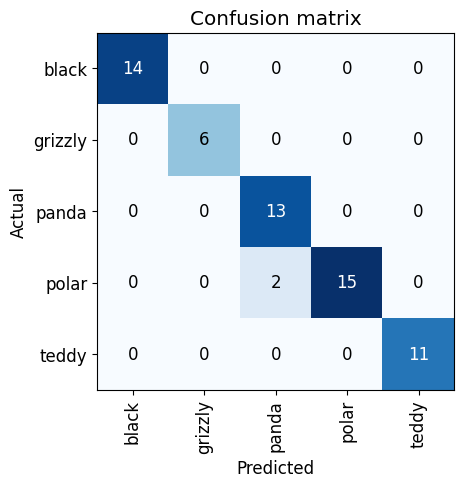

In [40]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

The rows represent all the categories in our dataset, respectively. The columns represent the images which the model predicted as black, grizzly, panda, polar and teddy bears, respectively. Therefore, the _diagonal of the matrix_ shows the images which were classified correctly, and teh off diagonals cells represent those whiche were classified incorrectly.

The goal is to have white everywhere except the diagonal, whre we want dark blue.

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

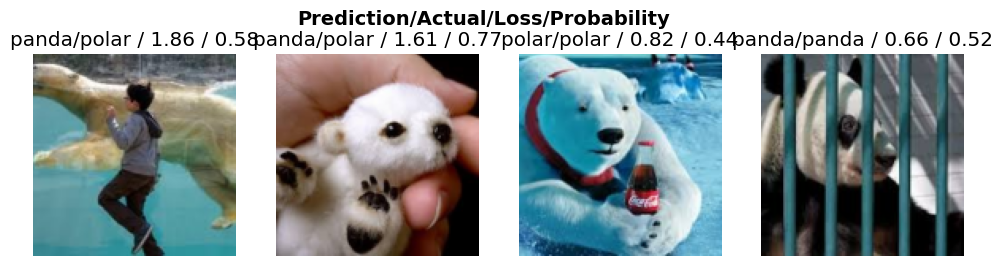

In [28]:
interp.plot_top_losses(4, nrows = 1)

This output shows that the image with the highest loss are the ones that has been predicted as "panda" and "grizzly" with high confidence. However, it's labeled as "polar" and "black".
_(grizzly and black are not shown in the output above)_

This intuitive approach to doing data cleaning is to do it _before_ you train a model. But as you have seen, in this case, a model can actually help you find data issues more quickly and easily. So, we normally prefer to train a quick and simple model first, and then use it to help us with data cleaning.

fastai includes a handy GUI for data cleaning called ***ImageClassifierCleaner*** that allows you to choose a category and the training versus validation set and view the highest-loss images (in order), along with menus to allow images to be selected for removal or relabeling

In [ ]:
cleaner = ImageClassifierCleaner(learn)
cleaner

We can see that amongst our "grizzly" is an image that contains two bears: one grizzly, one black. So, we should choose **<Delete>** in teh menu under this image. ***ImageClassifierCleaner*** doesn't actually do the deleting or changing of the labels for you; it just returns the indices of items to change. So, for instance, to delete (Unlink) all images selected for deletion, we would run:

In [30]:
# hide
for idx in cleaner.delete():
    cleaner.fns[idx].unlink()

To move images for which we've selected a different category, we would run:

In [31]:
# hide
for idx, cat in cleaner.change():
    shutil.move(str(cleaner.fns[idx]),path/cat)

The widget **cleaner** has trace each image that we decide to move:

- **idx**: it's the index of the image on the list of files

- **cat**: it's the new category(destination folder) that you choose from the menu of the widget

The **shutil.move(str(cleaner.fns[idx]), path/cat)** function is the action of moving files:

- **cleaner.fns[idx]**: return the current path of the correct image using its index

- **str(...)**: transform the path into a string(because shutil.move prefers to work with strings instead of paths)

- **path/cat**: defines the destination. Take the main path (path) and adds the name of the new category(cat), pointing the sub directory correctly (ex. from /bears/grizzly to /bears/black)

We'll be seeing more examples of model-driven data cleaning throught this book. Once we've cleaned up our data, we can retrain our model. Try it yourself, and see if your accuracy improves!

Since the model still have issues in recognize which bear is a polar or a bear, I'll try to load the dataset with a new argument called **batch_tfms** with function **aug_transforms()**.
This function create different versions of the images(rotated, zoomed or with different brightness), helping the model to not be fooled by the white color on the background.

I could have trained the model with more epochs, but doing so would risk ***overfitting***, which is when the model learns by heart and ends up recognizing only specific pixels in photos it hase already seen instead of learning what a panda or a polar bear actually is 

In [4]:
bears2 = DataBlock(
    blocks = [ImageBlock, CategoryBlock],
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct = 0.2, seed = 42),
    get_y = parent_label,
    item_tfms = Resize(224, ResizeMethod.Squish),
    batch_tfms = aug_transforms()
)


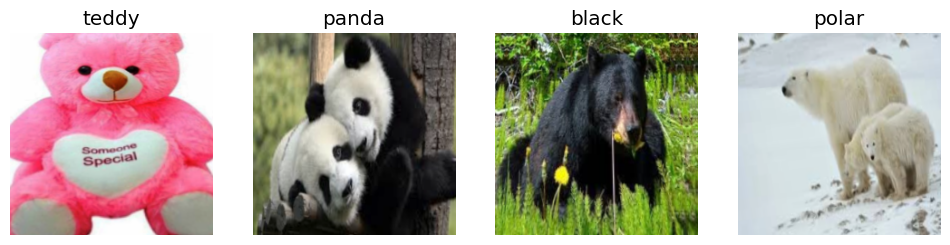

In [50]:
dls2 = bears2.dataloaders(path)
dls2.show_batch(max_n = 4, nrows = 1)

In [52]:
learn2 = vision_learner(dls2, resnet18, metrics = error_rate)
learn2.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,2.865903,1.219475,0.475410,00:36


epoch,train_loss,valid_loss,error_rate,time
0,1.120508,0.313948,0.114754,00:44
1,0.744876,0.074919,0.032787,00:51
2,0.535597,0.063629,0.032787,00:51
3,0.410490,0.068136,0.032787,00:47


In [ ]:
interp2 = ClassificationInterpretation.from_learner(learn2)
interp2.plot_confusion_matrix()

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

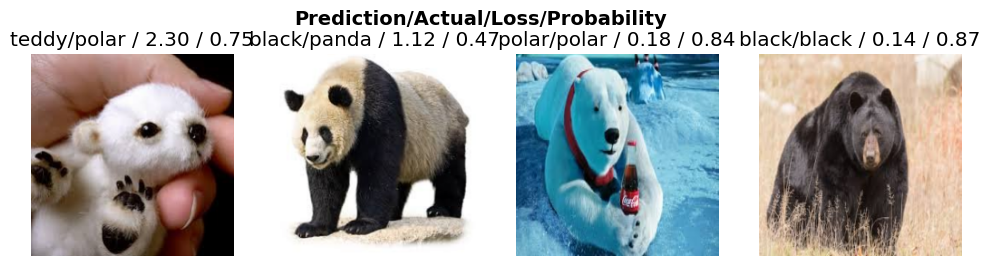

In [58]:
interp2.plot_top_losses(4, nrows = 1)

Now I can see which images are the false positives. So now we can retrieve the path of each false positives and clean them to have a perfect model that recognize each bear


In [ ]:
losses, idxs = interp2.top_losses(2)

for i, idx in enumerate(idxs):
    file_path = dls2.valid_ds.items[idx]
    file_path.unlink()
    print(f"Top {i+1} loss: {file_path}")


Top 1 loss: /home/davidebui/DeepLearning/Lesson2/Bear_dataset/data/polar/polar_bear99.jpg
Top 2 loss: /home/davidebui/DeepLearning/Lesson2/Bear_dataset/data/panda/panda43.jpg


## FINAl MODEL

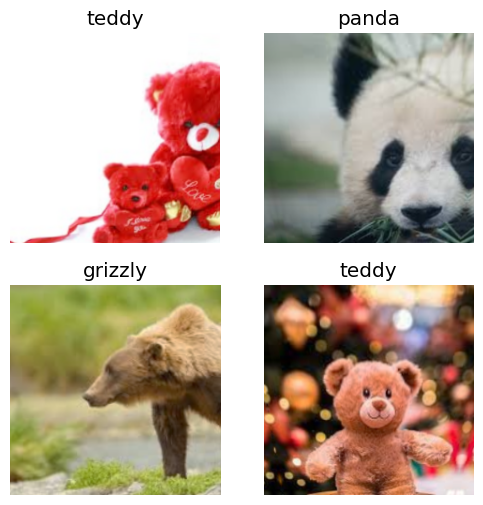

In [3]:
path = "/home/davidebui/DeepLearning/Lesson2/Bear_dataset"

final_dls = DataBlock(
    blocks = [ImageBlock, CategoryBlock],
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct = 0.2, seed = 42),
    get_y = parent_label,
    item_tfms = Resize(224),
    batch_tfms = aug_transforms()
).dataloaders(path)

final_dls.show_batch(max_n = 4)

In [4]:
final_learner = vision_learner(final_dls, resnet18, metrics = error_rate)
final_learner.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,2.741976,1.603077,0.557377,00:33


epoch,train_loss,valid_loss,error_rate,time
0,1.086529,0.546750,0.229508,00:44
1,0.807285,0.148270,0.016393,00:44
2,0.594018,0.115235,0.016393,00:39
3,0.453071,0.114367,0.016393,00:44


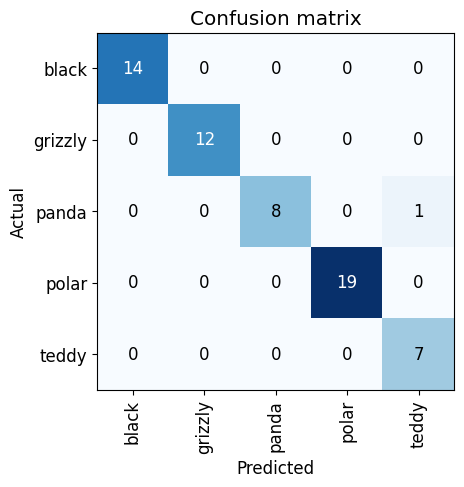

In [5]:
final_interp = ClassificationInterpretation.from_learner(final_learner)
final_interp.plot_confusion_matrix()

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

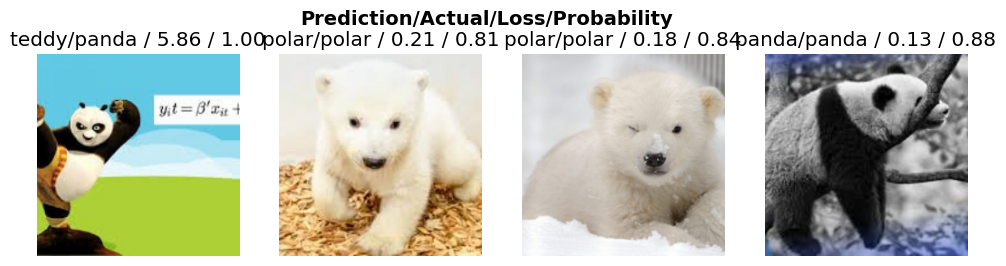

In [6]:
final_interp.plot_top_losses(4, nrows = 1)

## Turning Your Notebook into an online application

We are now going to look at what it takes to turn this model into a working online application. We will just go as far as creating a basic working prototype; we do not have the scoope to teach all the details of web application development generally.

### Using the model for inference

Once you've got a model you're happy with, you need to save it, so that you can then copy it over to a server where you'll use it in production. Remember that a model consists of two parts: the _architecture_ and the trained _parameters_. The easiest way to save the model is to save both of these, because that way when you load a model you can be sure that you have the matching architecture and parameters. To save both parts, use the ***export*** method.

This method even saves the definition of how to create your _DataLoaders_. This is important, because otherwise you would have to redefine how to transform your data in order to use your model in production. fastai automatically uses your validation set DataLoader for inference by default, so your data augmentation will not be applied, which generally what you want

 

When you call EXPORT, fastai will save a file called _"export.pkl"_

In [7]:
final_learner.export()

Let's check that the file exists, by using the _ls_ method that fastai adds to Python's path class:

In [8]:
path = Path()
path.ls(file_exts='.pkl')

[Path('export.pkl')]

You'll need this file wherever you deploy your app to. For now, let's try to create a simple app within our notebook.

When we use a model for getting predictions, instead of training, we call it _inference_. To create our inference learner from the exported file, we use ***load_learner*** (in this case, this isn't really necessary, since we already have a working Learner in our notebook; we're just doing it here so you can see the whole process end-to-end)

In [9]:
learn_inf = load_learner(path/'export.pkl')

/home/davidebui/miniforge3/envs/corso_ai/lib/python3.10/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


When we're doing inference, we're generally just getting predictions for one image at a time. To do this, pass a filename to predict:

In [14]:
path1 = Path('.')
img_path = path/'Bear_dataset'/'data'/'grizzly'/'grizzly2.jpg'

learn_inf.predict(img_path)

('grizzly',
 tensor(1),
 tensor([3.7474e-02, 9.6020e-01, 1.8573e-03, 9.2710e-05, 3.8014e-04]))

This has returned three things:

- The **predicted** category in the same format you originally provided

- The **index** of the predicted category

- The **probabilities** of each category

The last two are based on the order of categories in the vocab of teh dataloaders.

In [15]:
learn_inf.dls.vocab

['black', 'grizzly', 'panda', 'polar', 'teddy']

We can see here that if we index into the vocab with the integer retured by _predict_ then we get back "grizzly" as expected. Also, note that if we index into the list of probabilities, we see a nearly 1.00 probability that this is a grizzly.

We know how to make predictions from our saved model, so we have everything we need to start building our app. We can do it directly in a Jupyter notebook.

## Creating a notebook app from the model

We can simply treat the predict method as a regular function.
The two things we need to create a complete working web application using nothing but Jupyter notebook are:

- **IPython widgets** _(ipywidgets)_: Are GUI components that bring together JavaScript and Python functionality in a web browser, and can be created and used within a Jupyter notebook. However, we don't want to require users of our application to run Jupyter themselves.

- **Voilà**: It is a system for making applications consisting of IPython widgets available to end users, without them having to use Jupyter at all. Essentially, it helps us atuomatically convert the complex web application (the notebook) into a simpler, easier-to-deploy web application, which functions like a normal web application rather than like a notebook.

We still have the advantage of developing in a notebook, so with ipywidgets we can build up our GUI step by step. We will use this approach to create a simple image classifier. First, we need a file upload widget:


In [16]:
btn_upload = widgets.FileUpload()
btn_upload

FileUpload(value={}, description='Upload')

In [19]:
# for the book, we can't actually click an upload button, so we fake it

btn_upload = SimpleNamespace(data = [img_path])
img = PILImage.create(btn_upload.data[-1])

We can use an OUTPUT widget to display it:

In [21]:
# hide
out_pl = widgets.Output()
out_pl.clear_output()
with out_pl: display(img.to_thumb(128,128))
out_pl

Output()

Then we can get our predictions and use a Label to display them:

In [23]:
pred, pred_idx, probs = learn_inf.predict(img)
lbl_pred = widgets.Label()
lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'
lbl_pred

Label(value='Prediction: grizzly; Probability: 0.9602')

We'need a button to do the classification. It looks exactly like the upload button. We also need a _click event handler_; that is a function that will be called whn it's pressed.

In [ ]:
# hide
def on_click_classify(change):
    img = PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl: display(img.to_thumb(128,128))
    pred, pred_idx, probs = learn_inf.predict(img)
    lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'

btn_run = widgets.Button(description = 'Classify')
btn_run
btn_run.on_click(on_click_classify)

You can test the button now by pressing it, and you should see the image and predictions update automatically! We can now put htem all in a vertical box to complete our GUI:

In [26]:
# hide
# putting back btn_upload to a widget for next cell

btn_upload = widgets.FileUpload()

VBox([widgets.Label('Select your bear!'),
    btn_upload, btn_run, out_pl, lbl_pred])

We have written all the code necessary for our app. The next step is to convert it into something we can deploy.

## Turning your notebook into a real app

In [ ]:
#hide
# !pip install voila
# !jupyter serverextension enable --sys-prefix-voila

Now that we have everything working in this Jupyter notebook, we can create our application. To do this, start a new notebook and add to it only the code needed to create and show the widgets that you need, and markdown for any text that you want to appear

In [28]:
!pip install voila
!jupyter serverextension enable --sys-prefix voila

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: dejavu events execute kernel kernelspec lab
labextension labhub migrate nbconvert notebook run server troubleshoot trust

Jupyter command `jupyter-serverextension` not found.


Voilà runs Jupyter notebook just like the Jupyter notebook server you are using now, but it also does something very important: it removes all of the cell inputs, and only shows output (including ipywidgets), along with your markdown cells. So what's left is a web application! 

_To view your notebook as a Voilà web application, replace the word "notebooks" in your browser's URL with: "voila/render". You will see the same content as your notebook, but without any of the code cells_

Of course, you don't need to use Voilà or ipywidgets. Your model is just a function you can call (pred,pred_idx,probs = learn.predict(img)), so you can use it with any framework, hosted on any platform. And you can take something you've prototyped in ipywidgets and Voilà and later convert it into a regular web application

We have our app, now let's deploy it!

### Deploying your app

Because of the complexity of GPU serving, many systems have sprung up to try to automate this. However, managing and running these systems is also complex, and generally requires compiling your model into a different form that's specialized for that system. It's typically preferable to avoid dealing with this complexity until/unless your app gets popular enough that it makes clear financial sense for you to do so

For at least the initial prototype of the application, and for any hobby projects that you want to show off, you can easily host them for free. The simplest and free approach is to use **Binder**. 
To publish your web app on Binder, you need to follow these steps:

1. Add your notebook to a GitHub repo.
2. Paste the URL of that repo into Binder's URL, as shown in <>.
3. Change the File dropdown to instead select URL.
4. In the "URL to open" field, enter /voila/render/name.ipynb (replacing name with the name of for your notebook).
5. Click the clickboard button at the bottom right to copy the URL and paste it somewhere safe.
6. Click Launch

GitHub repository name or URL:
https://github.com/BKarmaVTH/Practical-Deep-Learning

URL to open:
voila/render/Lesson2/Bear_classifier/app.ipynb

This is the link to access the classifier:
https://mybinder.org/v2/gh/BKarmaVTH/Practical-Deep-Learning/main?urlpath=voila%2Frender%2FLesson2%2FBear_classifier%2Fapp.ipynb

The first time you do this, Binder will take around 5 minutes to build your site. Behind the scenes, it is finding a virtual machine that can run your app, allocating storage, collecting the files needed for Jupyter, for your notebook, and for presenting your notebook as a web application.

Finally, once it has started the app running, it will navigate your browser to your new web app. You can share the URL you copied to allow others to access your app as well

Deploying a model directly into a mobile application tends to require a lot of extra steps and boilerplate, and does not always support all the PyTorch and fastai layers that your model might use. Instead, we recommend wherever possible that you deploy the model itself to a server, and have your mobile or edge application connect to it as a web service. 

This approach makes the initial installation easier, because you only have to deploy a small GUI application which connects to the server to do all the heavy lifting; more importantly, upgrades of that core logic can happen on your server, rather than needing to be distributed to all of your users. While there are downsides, such as the requirement of a network connection and potential concerns about sensitive data, your server will have a lot more memory and processing capacity than most edge devices, and it is far easier to scale those resources if your model becomes more demanding.

Overall, we'd reccomend using a simple CPU-based server approach where possible, for as long as you can get away with it.

Congratulations, you have successfully built a deep learning model and deployed it.